# Acrobot Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的目标是先展示在 Acrobot 这种双连杆摆动控制任务里，如果完全随机地施加离散力矩，系统通常会在多长时间内接近目标高度，以及随机摆动为什么很难稳定完成上摆过程。这个 baseline 会作为后续 `DQN` notebook 的参照，用来说明为什么仅靠随机试错几乎不可能形成有效的能量积累策略。


## 环境背景

Acrobot 是一个双连杆摆动控制环境。智能体不能直接驱动底座，而是通过关节上的离散力矩，让系统逐步积累动能，把末端摆到足够高的位置。这个任务的难点在于：

- 状态是连续的
- 成功依赖一串连贯的能量传递动作
- 错误动作不会立刻失败，但会浪费大量时间

因此，它很适合用来说明：某些控制任务的难点不在于单步决策，而在于是否能形成跨多个时间步的协调摆动模式。


## 方法说明

这里的方法就是纯随机动作采样：每一步直接从动作空间中随机选择力矩，不维护价值函数，也不更新策略。它不是正式算法，但它能非常直观地说明这个环境为什么不能依赖随机摆动来解决。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是环境交互统计，不涉及神经网络训练。


In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "Acrobot-v1"
NUM_EPISODES = 1000
MAX_STEPS = 500
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SEED = 42
SUCCESS_THRESHOLD_RETURN = -100

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)


## 参数选择说明

- `NUM_EPISODES = 1000`：让随机策略的统计结果足够稳定，同时保持执行速度可控
- `MAX_STEPS = 500`：与 `Acrobot-v1` 的标准回合上限一致
- `SUCCESS_THRESHOLD_RETURN = -100`：把平均回报优于 `-100` 作为接近求解标准的近似判断线

这里的重点不是训练，而是建立一个清晰的能量积累基线：随机摆动通常会让回合长度接近上限，很难形成有效的上摆轨迹。


In [3]:
episode_rewards = []
episode_lengths = []
successes = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))

    episode_rewards.append(total_reward)

env.close()


Random episodes:   0%|          | 0/1000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
    }
)
summary.describe(include="all")


,reward,episode_length,success
count,1000.000000,1000.000000,1000.0
mean,-498.885000,498.902000,0.0
std,10.853828,10.753047,0.0
min,-500.000000,322.000000,0.0
25%,-500.000000,500.000000,0.0
50%,-500.000000,500.000000,0.0
75%,-500.000000,500.000000,0.0
max,-321.000000,500.000000,0.0


In [5]:
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))
success_rate = float(np.mean(successes))

metrics = pd.DataFrame(
    {
        "metric": ["average_reward", "average_episode_length", "success_rate"],
        "value": [avg_reward, avg_length, success_rate],
    }
)
metrics


,metric,value
0,average_reward,-498.885
1,average_episode_length,498.902
2,success_rate,0.000


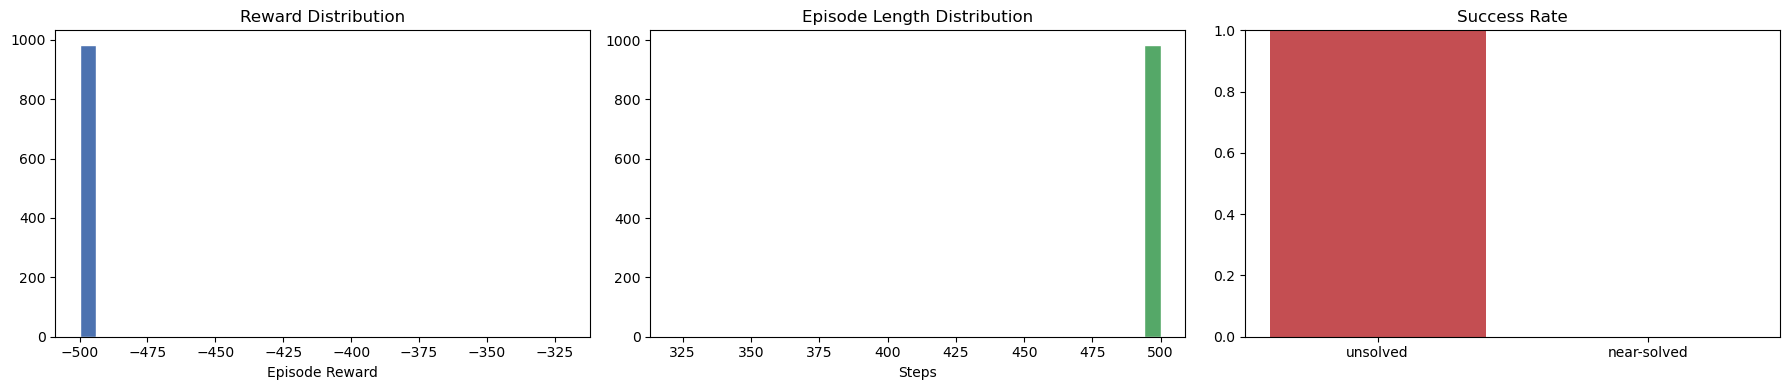

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")

axes[1].hist(episode_lengths, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].bar(["unsolved", "near-solved"], [1 - success_rate, success_rate], color=["#c44e52", "#8172b3"])
axes[2].set_title("Success Rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 1000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)

        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward

        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            rollout_summaries.append(
                {
                    "rollout_index": rollout_idx + 1,
                    "seed": SEED + 1000 + rollout_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                }
            )
            break

    rollout_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)

metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "random_baseline_rollout_summary.csv", index=False)

print(f"Average reward: {avg_reward:.2f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Success rate: {success_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Average reward: -498.88
Average episode length: 498.90
Success rate: 0.0000
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/09-acrobot-dqn/results


## 结果解读

随机策略在 Acrobot 里通常很难形成有效的能量积累过程，平均回报会接近回合上限对应的负值，成功率几乎为零。这说明这个任务真正要求学到的是多步协调摆动模式，而不是简单随机施力。
